In [1]:
%matplotlib widget
from lines import REDUC_LINES
from corr import REDSHIFT, SPECTRALDATA, MW_DUST_CORR, BALMER_ABS, CONTINUUM_SUBSTRACT
from new_lines import fitting_lines, a_ratio_dist, save_data, fit_auroral_new, save_data_auroral_MC

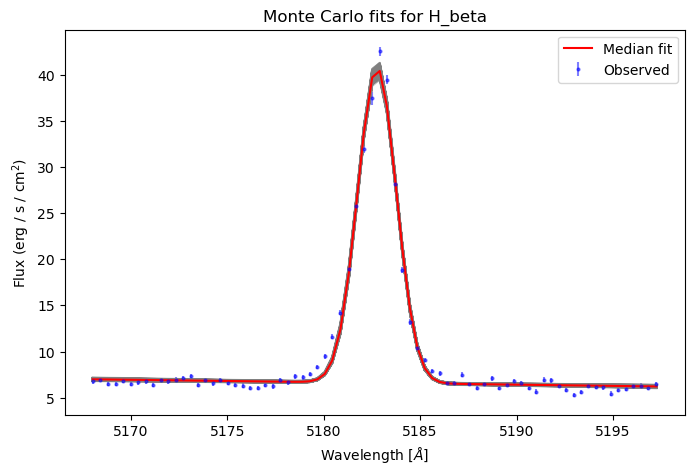

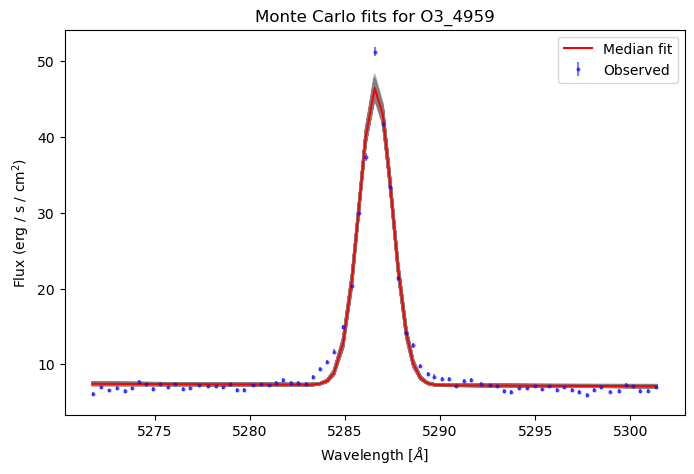

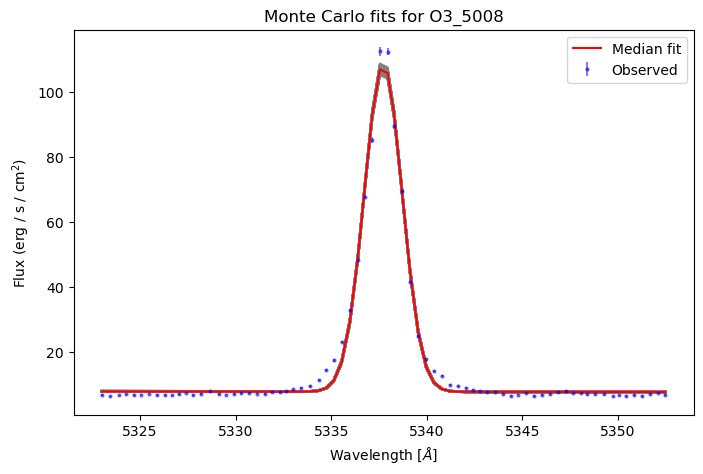

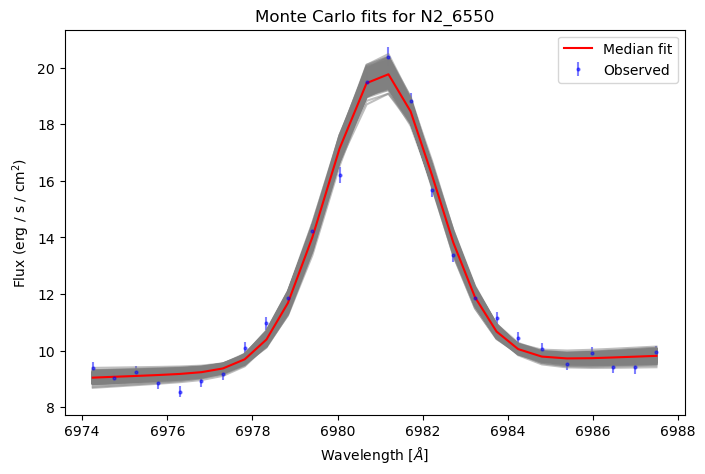

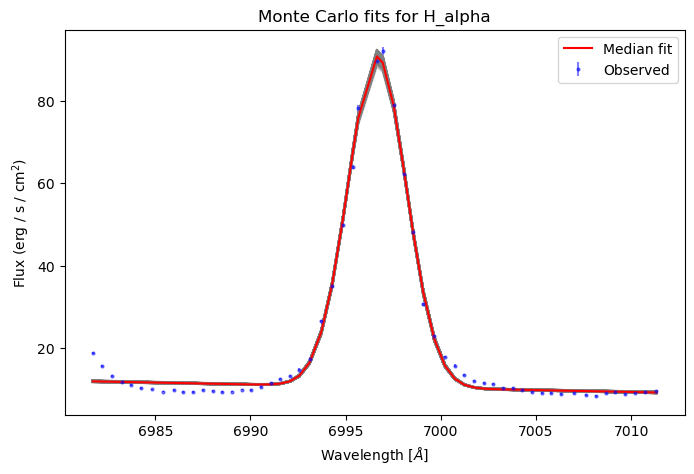

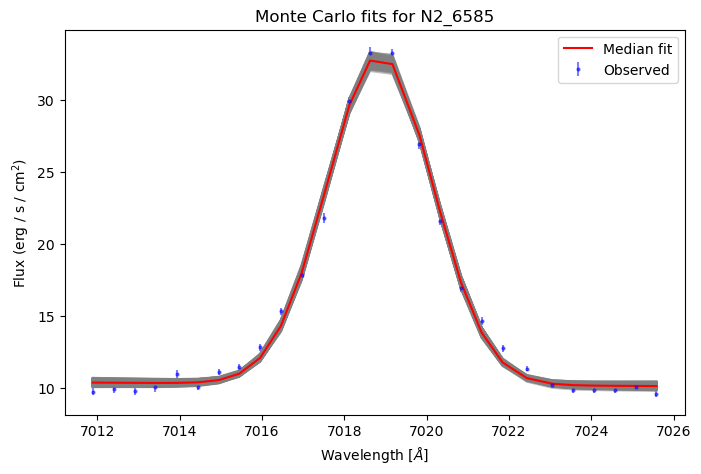

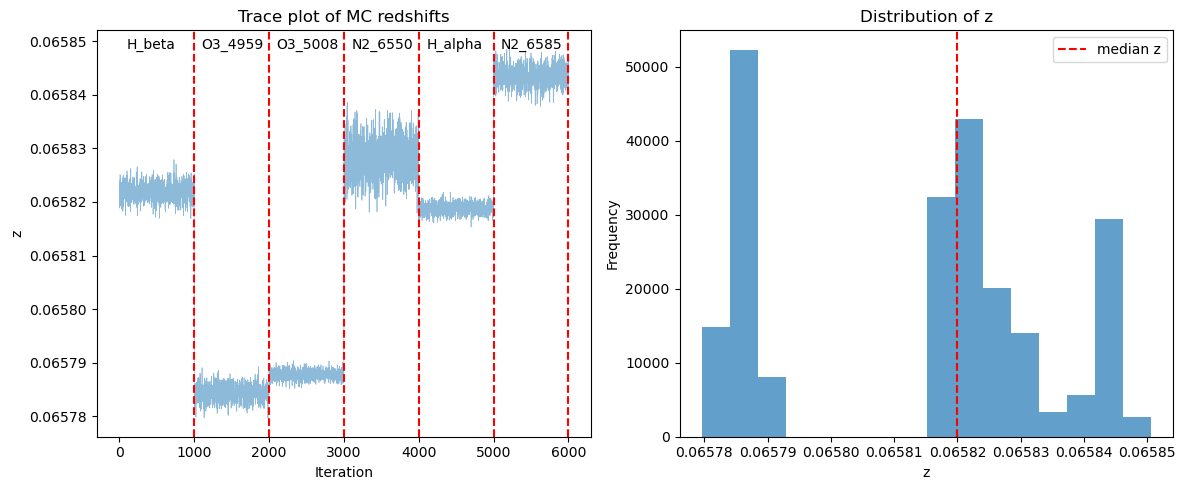

New redshift calculated for no_very_flats,z = 0.06581995171948551
Executed reset_redshift in 58.3804s


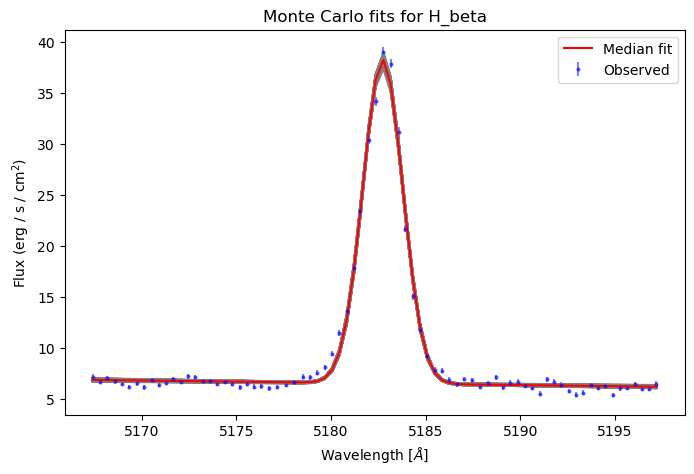

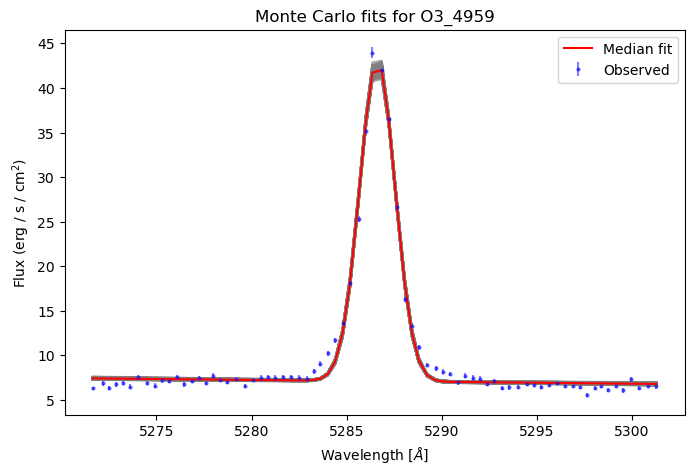

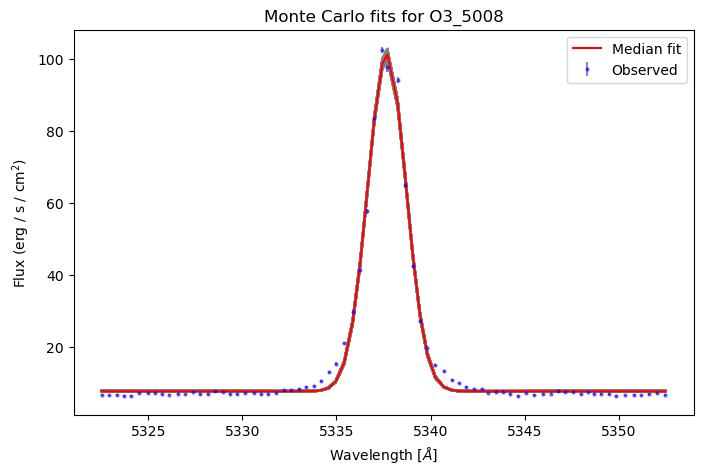

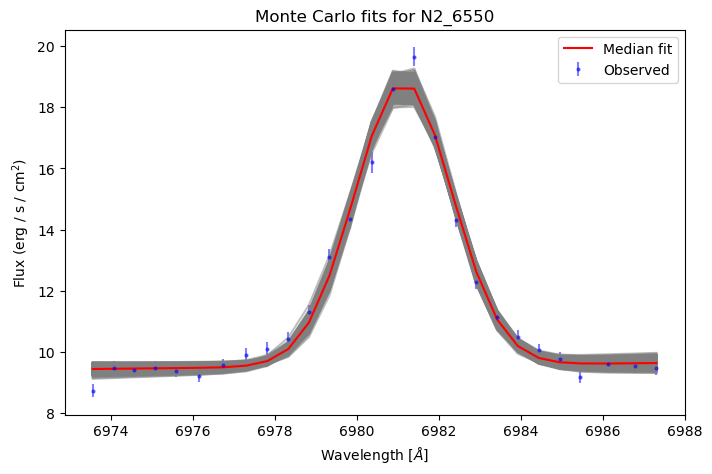

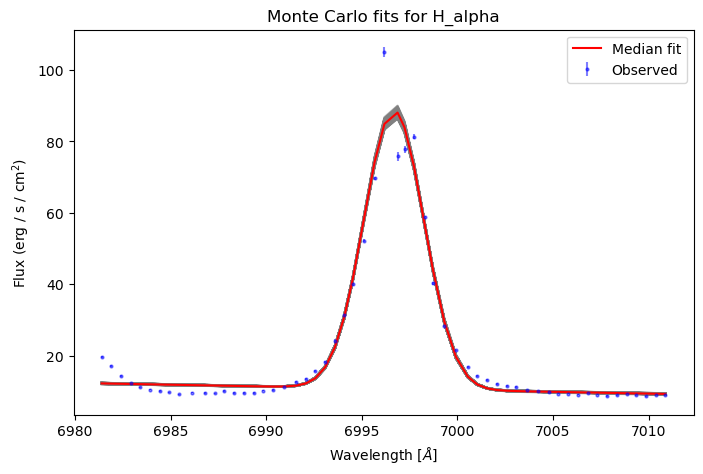

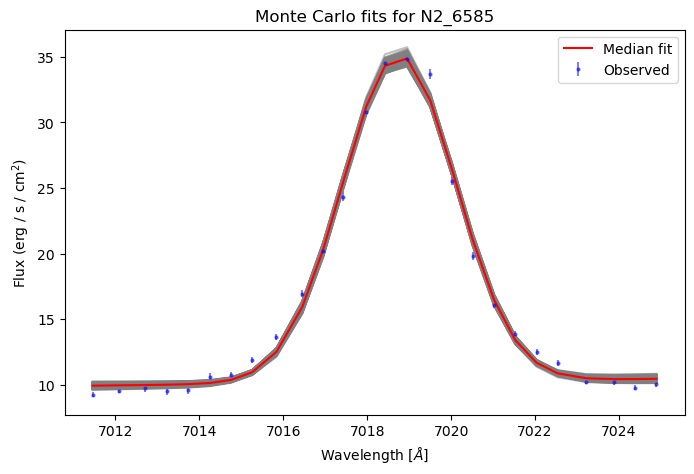

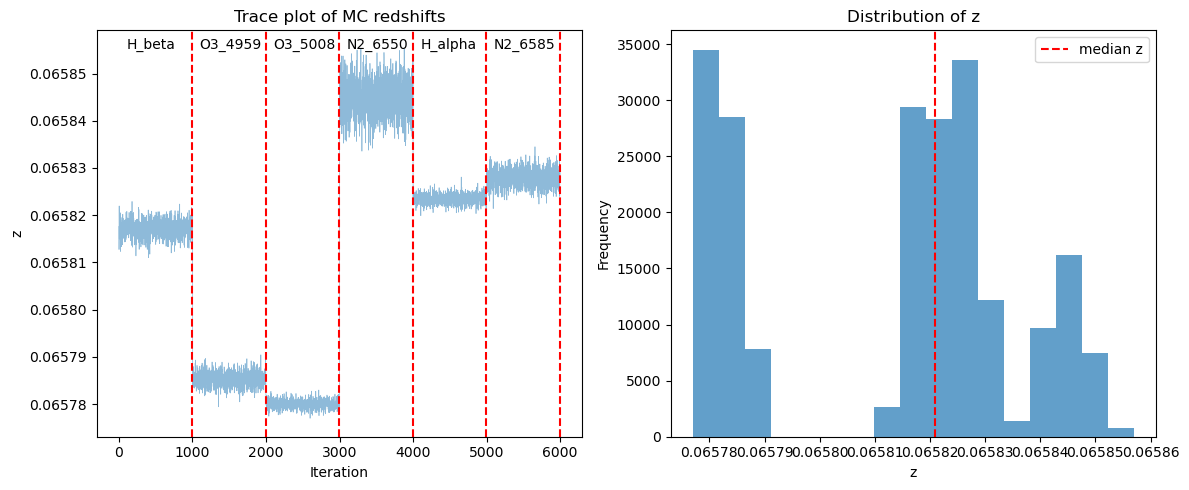

New redshift calculated for twilight,z = 0.06582095810349142
Executed reset_redshift in 65.1144s
New redshift for J0404+0538,z = 0.06581995171948551
Reading data for J0404
Using MW dust + Balmer abs corrected and continuum substracted data
Starting MC iteration
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done
faint
faint done
bright
bright done

,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0404+0538,10.2,0.065803,H_14,8.015159e-01,0.389262,7.965013e-01,0.387181,9.888375e-05,0.022598
1,J0404+0538,10.2,0.065803,O2_3725,1.145166e+02,1.277758,5.889951e+01,5.519146,5.568473e+01,6.078170
2,J0404+0538,10.2,0.065803,O2_3727,1.333971e+02,1.378979,6.354037e+01,5.484305,6.974939e+01,5.045229
3,J0404+0538,10.2,0.065803,H_13,8.747624e-01,0.416968,8.633237e-01,0.410864,6.833175e-06,0.102652
4,J0404+0538,10.2,0.065803,H_12,3.322094e-01,0.399606,1.625477e-01,0.193829,1.691818e-01,0.209335
5,J0404+0538,10.2,0.065803,H_11,2.971645e+00,0.544872,1.395728e+00,0.282228,1.521644e+00,0.310088
6,J0404+0538,10.2,0.065803,H_10,2.043174e+00,0.578012,9.485900e-01,0.288137,1.093619e+00,0.308770
7,J0404+0538,10.2,0.065803,H_9,6.488066e+00,0.555614,3.068589e+00,0.371215,3.412408e+00,0.395255
8,J0404+0538,10.2,0.065803,Ne3_3868,2.232309e+01,0.707100,1.046049e+01,1.052235,1.194507e+01,0.885326
9,J0404+0538,10.2,0.065803,He1_3898,1.649903e+01,0.733606,7.689307e+00,0.714989,8.682433e+00,0.789498


In [1]:
from fit_lines import save_data
J0404_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/38-J0404/',
    'FILES': ['no_very_flats/J0404_NO_VERY_FLATS_tellcorr.fits', 'twilight/J0404_TWILIGHT_tellcorr.fits'],
     'redshift': 0.066,
     'names':['J0404+0538'],
     'mass':10.2
}
save_data(J0404_SPECTRA, 100)

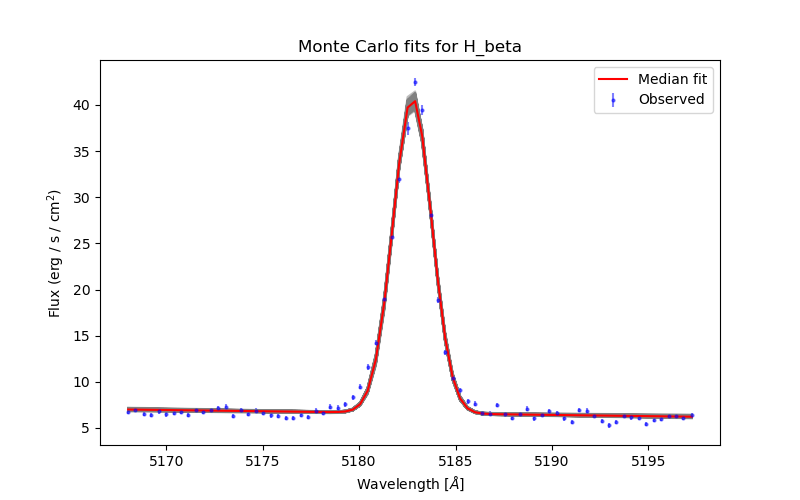

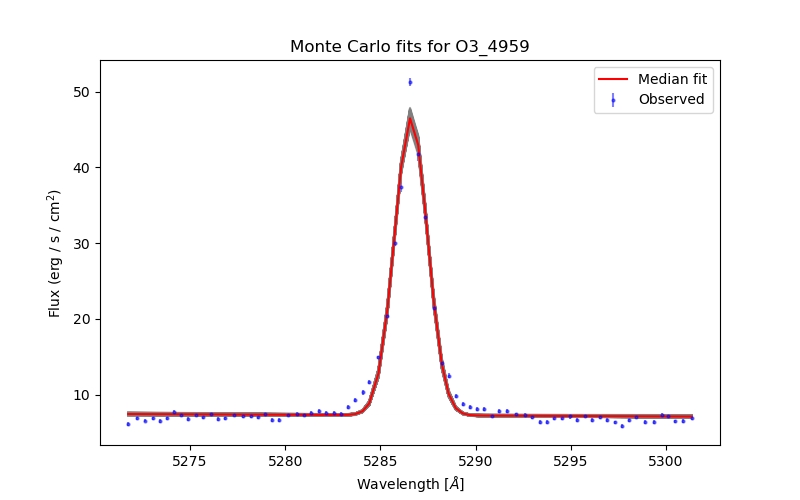

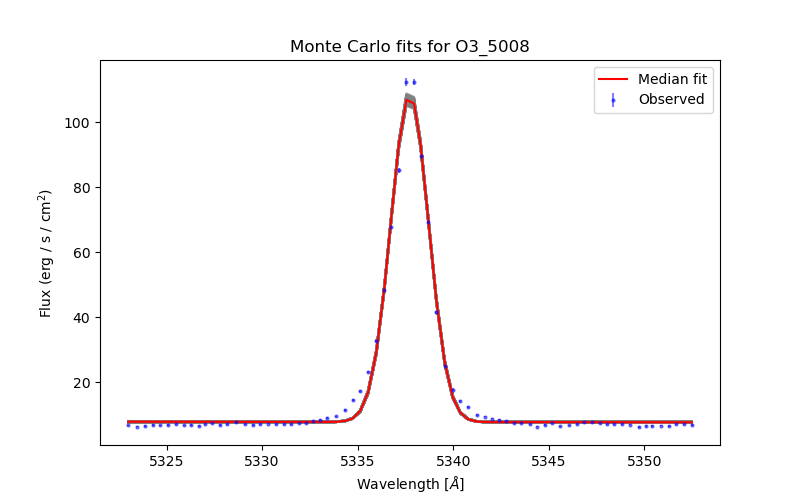

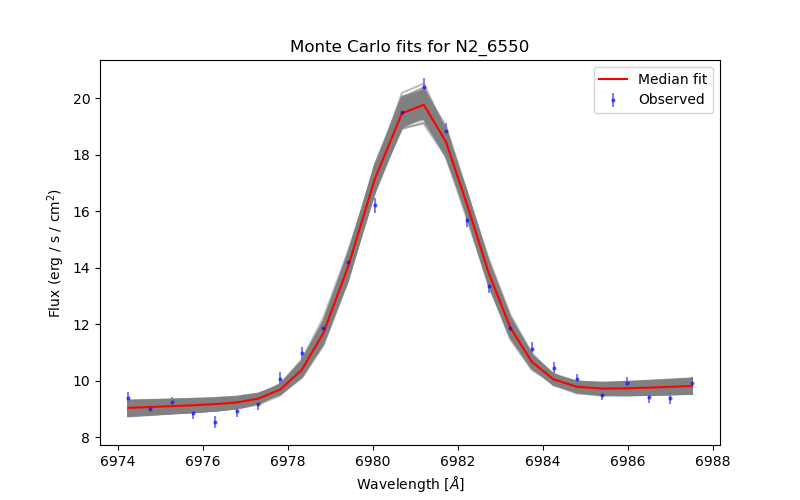

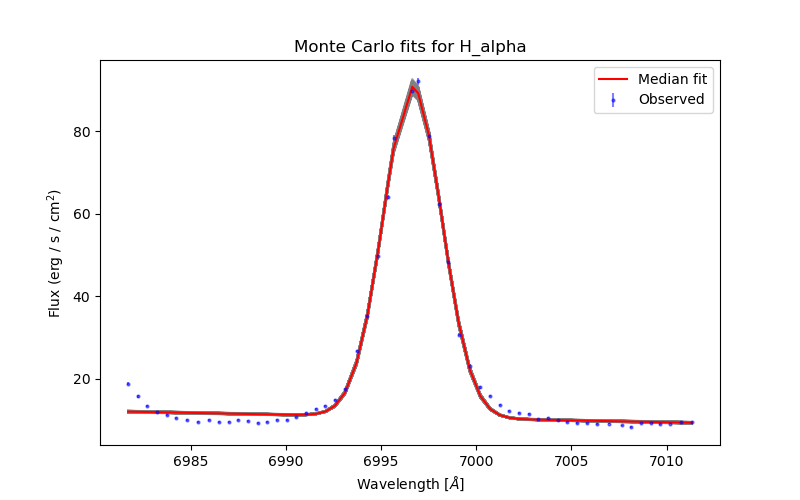

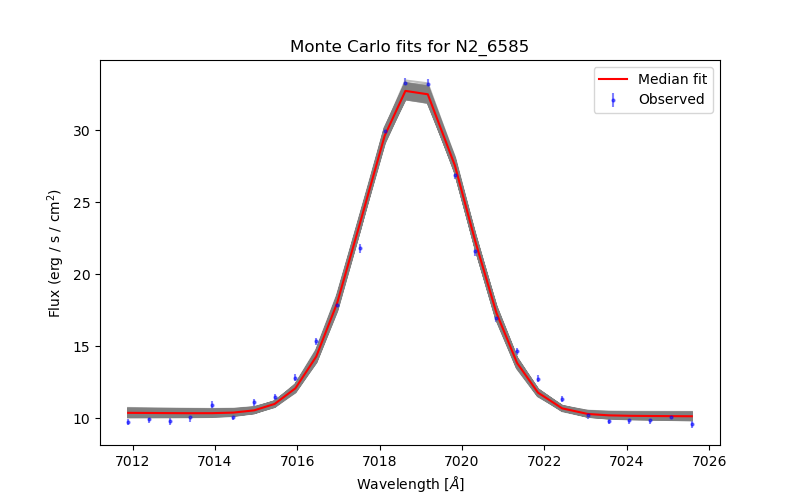

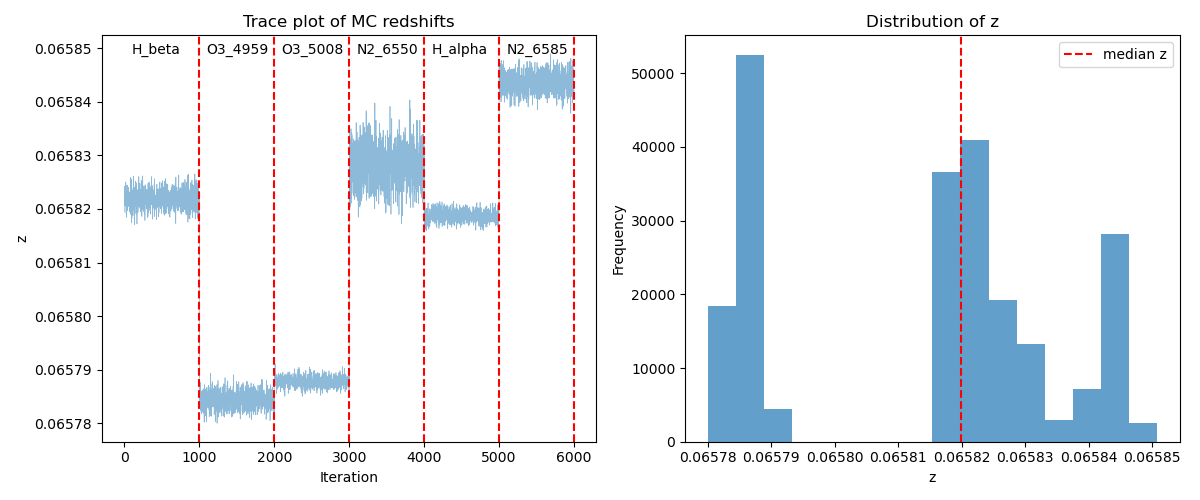

New redshift calculated for no_very_flats,z = 0.06581992159997241
Executed reset_redshift in 48.7050s


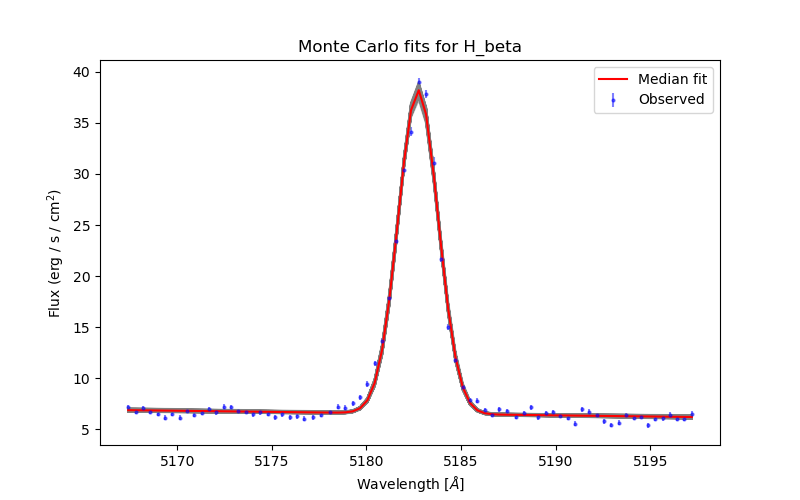

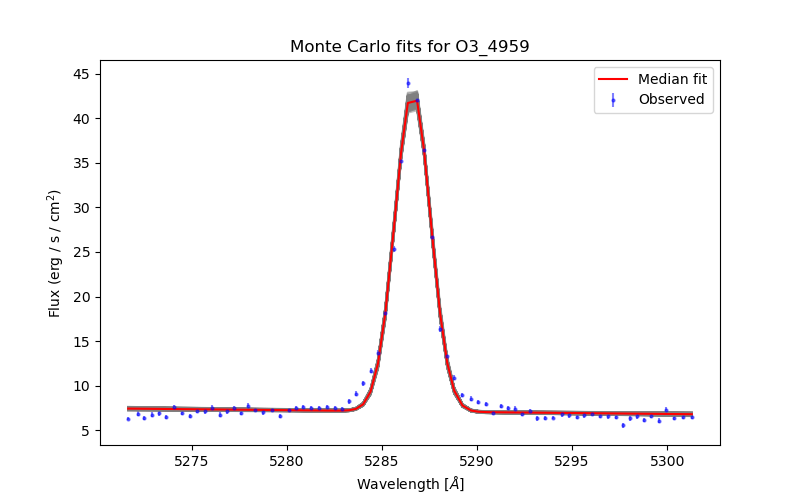

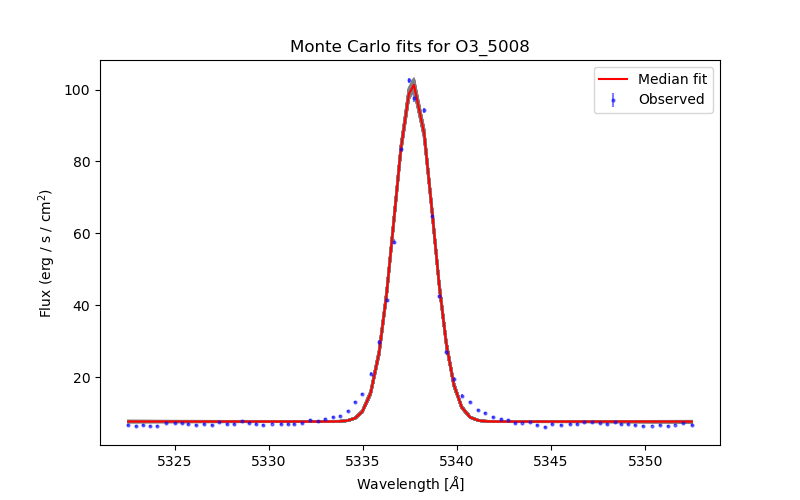

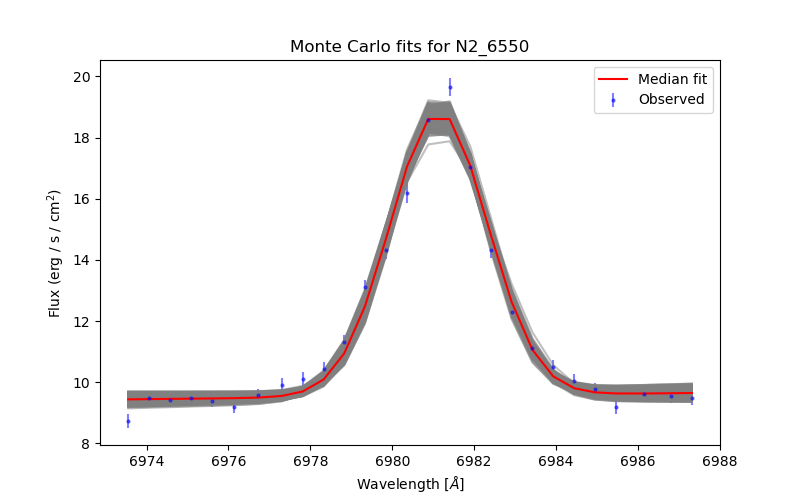

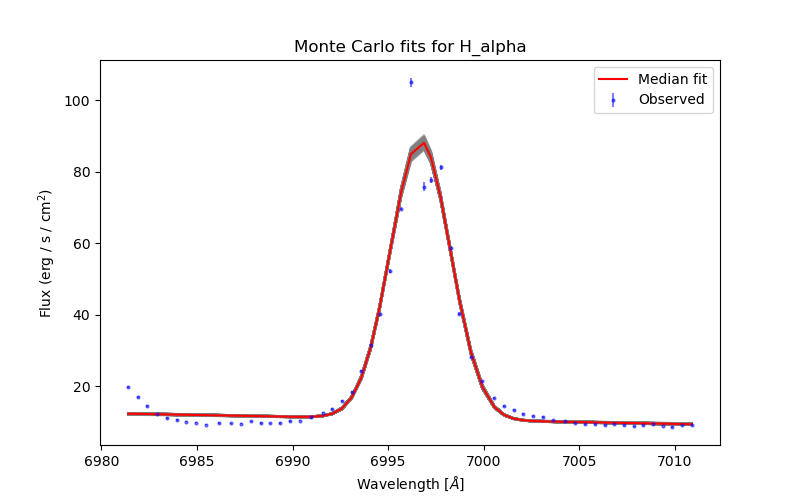

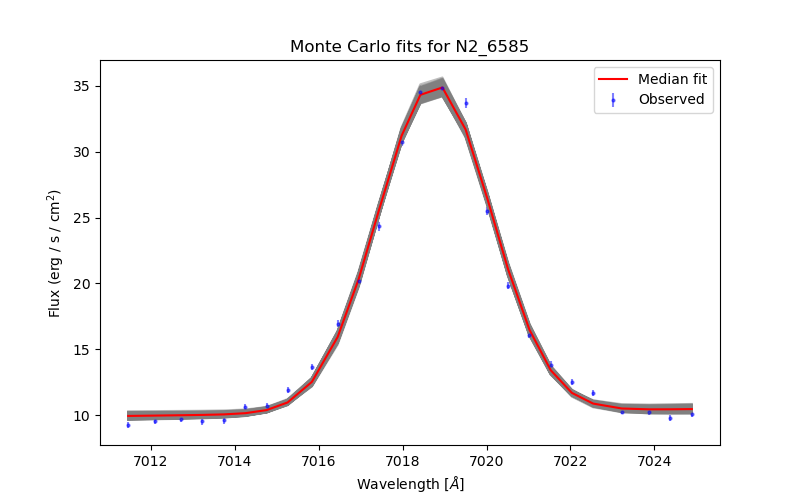

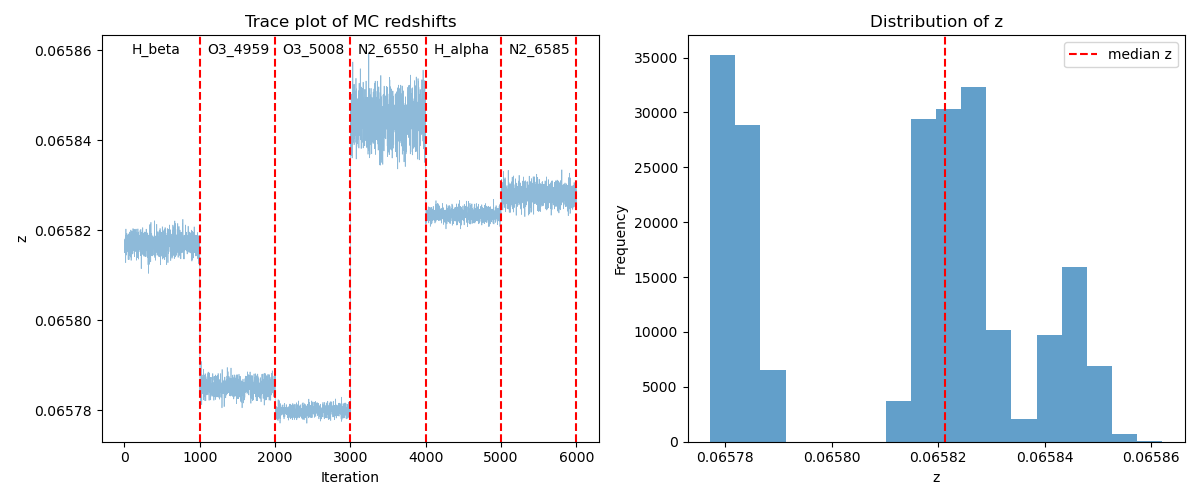

New redshift calculated for twilight,z = 0.06582119548666432
Executed reset_redshift in 47.5859s
New redshift for J0404+0538,z = 0.06581992159997241


In [2]:
J0404_SPECTRA= {
    'DIR':'/Users/javieratoro/Desktop/thesis/BAADE_DATA/testing/38-J0404/',
    'FILES': ['no_very_flats/J0404_NO_VERY_FLATS_tellcorr.fits', 'twilight/J0404_TWILIGHT_tellcorr.fits'],
     'redshift': 0.066,
     'names':['J0404+0538'],
     'mass':10.2
}
J0404 = SPECTRALDATA(J0404_SPECTRA)
z = REDSHIFT(J0404)

Reading data for J0404
Using MW dust + Balmer abs corrected and continuum substracted data


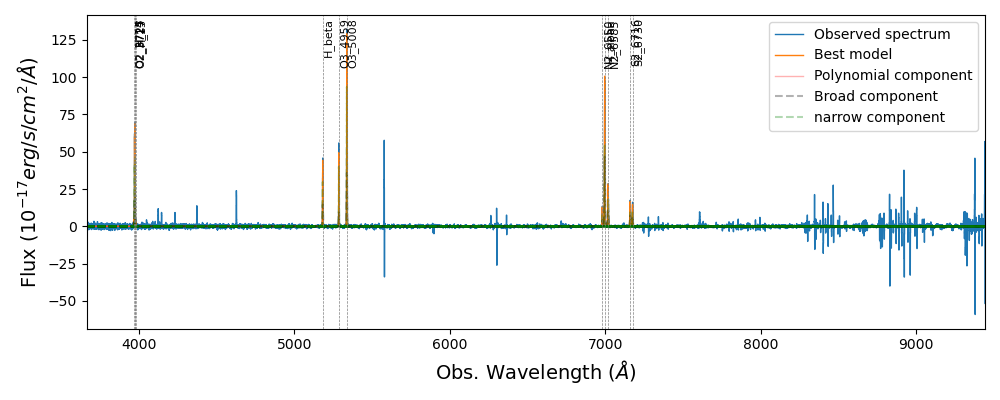

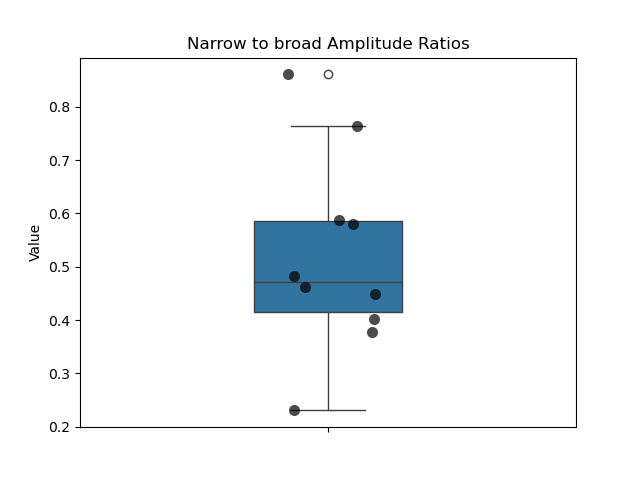

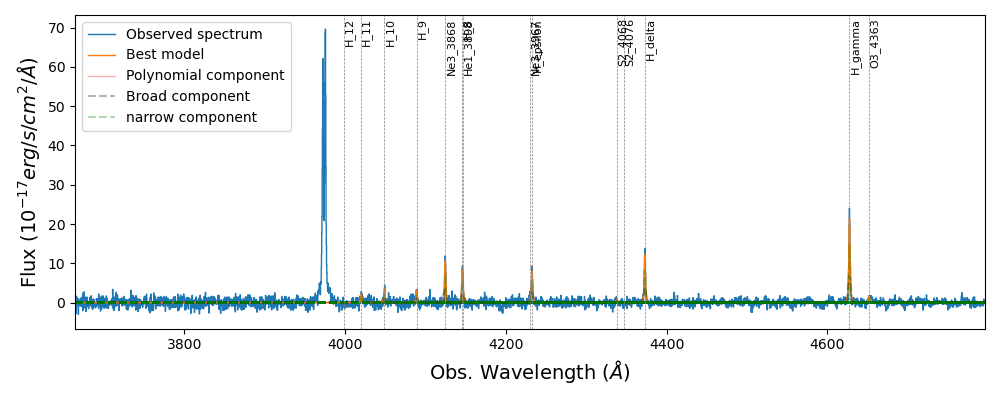

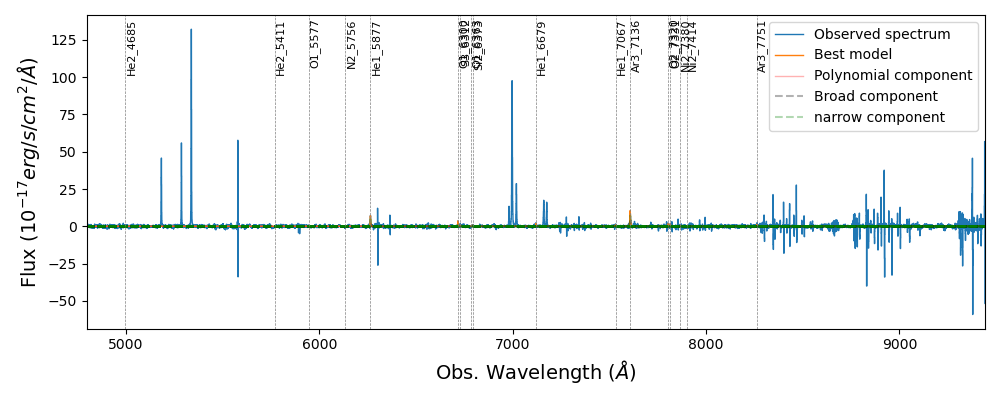

In [3]:
red = REDUC_LINES(J0404)
linelist = red.spectra.linelist_dict
bright_lines = ['H_14', 'H_13', 'O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585',
                'S2_6716','S2_6730']

bright_dict = {k: v for k, v in linelist.items() if k in bright_lines}
faint_dict  = {k: v for k, v in linelist.items() if k not in bright_lines}

mask = (red.wave < 4500*(1+red.spectra.redshift))
wave1, flux1, sigma1 = red.wave[mask], red.flux[mask], red.sigma[mask]
wave2, flux2, sigma2 = red.wave[~mask], red.flux[~mask], red.sigma[~mask]

blue_lines_b = {k:v for k,v in bright_dict.items() if v < 4500}
red_lines_b  = {k:v for k,v in bright_dict.items() if v >= 4500}

blue_lines_f = {k:v for k,v in faint_dict.items() if v < 4500}
red_lines_f  = {k:v for k,v in faint_dict.items() if v >= 4500}

lines = red.spectra.linelist_dict
blue_lines = {k:v for k,v in lines.items() if v < 4500}
red_lines = {k:v for k,v in lines.items() if v >= 4500}


init = fitting_lines(red.wave, red.flux,
                    bright_dict,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=None, A_ratio=None)
ratios = a_ratio_dist(init, plot=True)

out_blue = fitting_lines(wave1, flux1,
                    blue_lines_f,
                    z_init=red.spectra.redshift, plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

out_red = fitting_lines(wave2, flux2,
                    red_lines_f,
                    z_init=red.spectra.redshift,plot=True,
                    nfev=1000, fit=init, A_ratio=ratios)

In [4]:
save_data(red, 100)

Starting MC iteration
Saving in /Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/J0404/


,ID,mass,z_red,z_blue,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0404+0538,10.2,0.065799,0.065823,H_14,1.012389e+01,1.066067,2.387415e+00,0.795615,7.736247e+00,1.512939
1,J0404+0538,10.2,0.065799,0.065823,O2_3725,1.284486e+02,1.937320,6.557271e+01,4.886362,6.277072e+01,4.641860
2,J0404+0538,10.2,0.065799,0.065823,O2_3727,1.330673e+02,1.778561,7.977572e+01,4.865904,5.341089e+01,4.791575
3,J0404+0538,10.2,0.065799,0.065823,H_13,1.157614e+01,0.793347,1.009970e+00,0.821230,1.057471e+01,1.300421
4,J0404+0538,10.2,0.065799,0.065823,H_12,1.100045e-04,0.239802,1.100045e-04,0.239802,0.000000e+00,0.000000
5,J0404+0538,10.2,0.065799,0.065823,H_11,3.463892e+00,0.453629,3.463892e+00,0.453629,0.000000e+00,0.000000
6,J0404+0538,10.2,0.065799,0.065823,H_10,5.437634e+00,0.465132,5.437634e+00,0.465132,0.000000e+00,0.000000
7,J0404+0538,10.2,0.065799,0.065823,H_9,5.153667e+00,0.509462,5.153667e+00,0.509462,0.000000e+00,0.000000
8,J0404+0538,10.2,0.065799,0.065823,Ne3_3868,1.819020e+01,0.622829,1.819020e+01,0.622829,0.000000e+00,0.000000
9,J0404+0538,10.2,0.065799,0.065823,He1_3898,1.344116e+01,0.621530,1.344116e+01,0.621530,0.000000e+00,0.000000


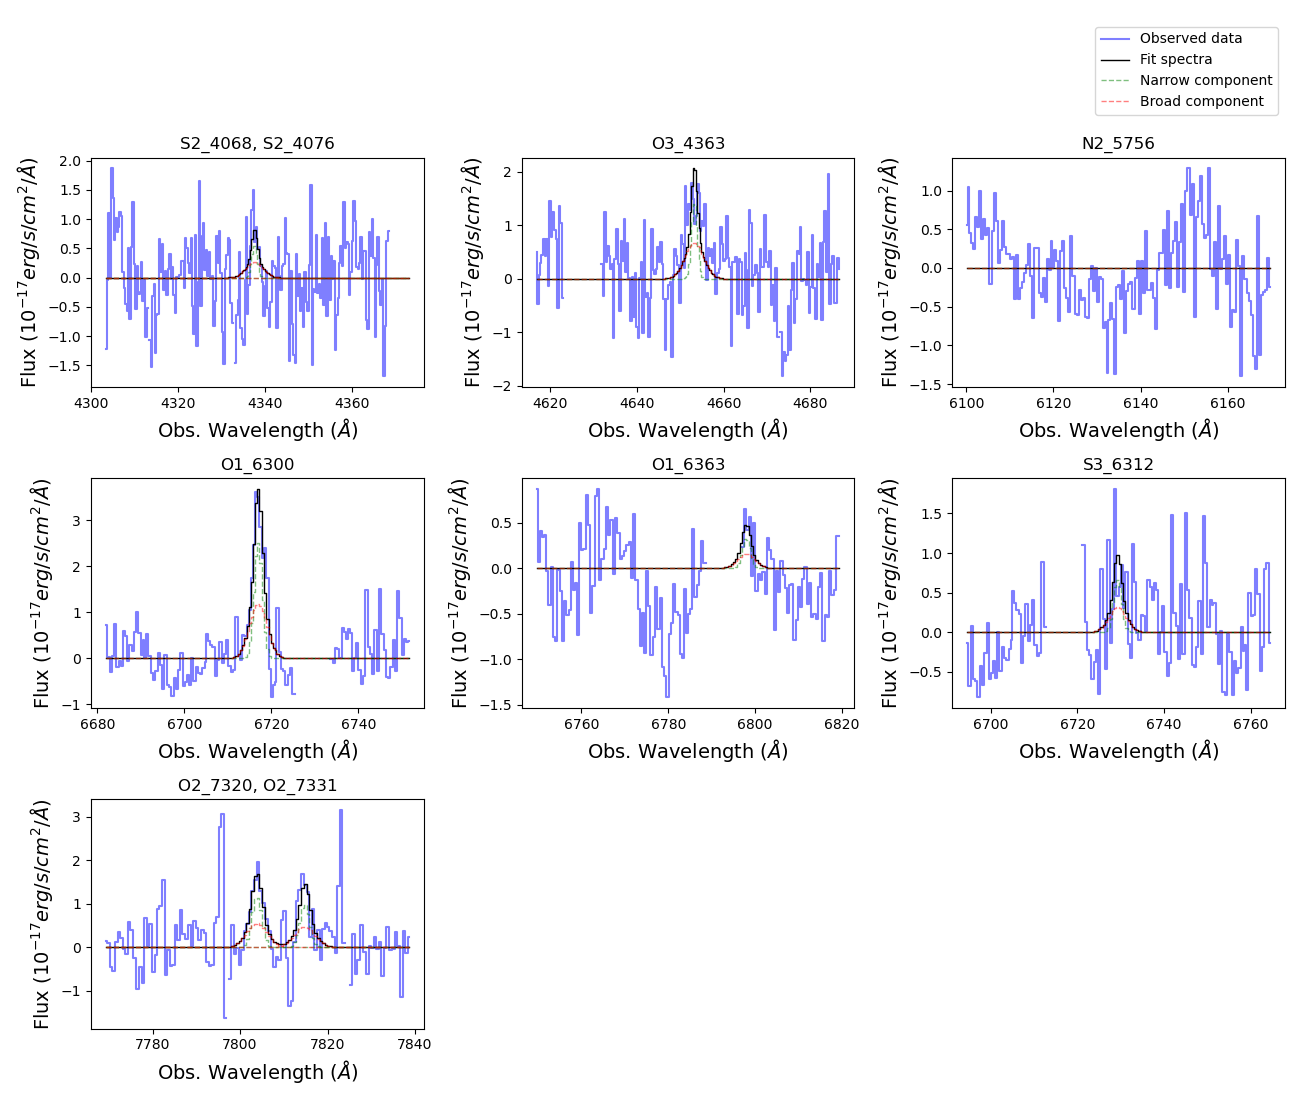

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/new_lines.py:543: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  comps.append(fit)


In [5]:
a, b = fit_auroral_new(red, ratio=ratios, flux_=red.flux, showplot=True)
info, res = save_data_auroral_MC(red, ratio=ratios, num=100)

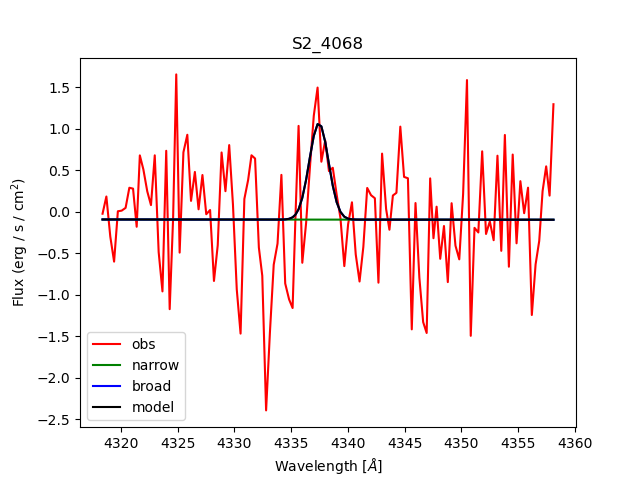

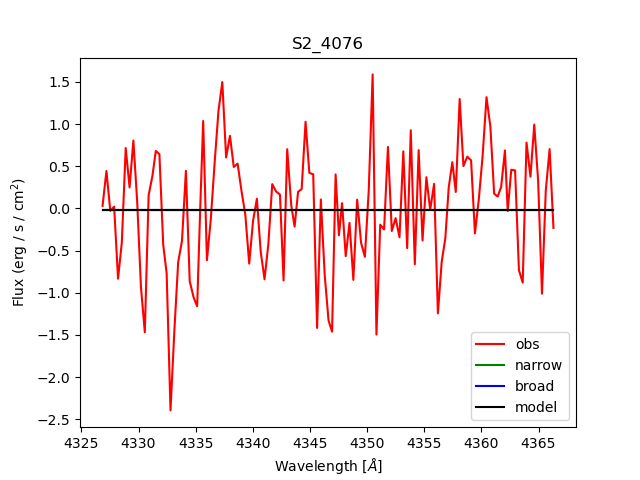

In [8]:
from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# get data
name= 'J0404'
save_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/{name}/cont_corr_{name}.csv'
dcorr = pd.read_csv(save_path)
wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

# stamp
labels = 'S2_4068', 'S2_4076'
class_ = J0404
df = pd.read_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')
for label in labels:
    wave_rest = class_.linelist_dict[label]
    wave_obs = wave_rest * (1 + class_.redshift)
    mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
    wave_stamp, flux_stamp = wave[mask], flux[mask]
    sigma_stamp = dcorr['sigma'][mask]

    # model
    narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
    broad_gaussian = GaussianModel(prefix=label+'_broad_')

    # Create a polynomial model for the continuum
    polydeg = 1
    polynomial = PolynomialModel(degree=polydeg)

    sum_of_gaussians = narrow_gaussian + broad_gaussian

    comp_mult = sum_of_gaussians + polynomial
    pars_mult = comp_mult.make_params()

    pars_mult.add(name='z', value=class_.redshift, vary=True)

    pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
    pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

    for param in ['center', 'amplitude', 'sigma']:
        narrow_key = f'{label}_narrow_{param}'
        if param == 'center':
            value = wave_rest
            vary = True
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 1
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
        pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                            vary=vary, expr=expr,
                                            min=0.0)


    for param in ['center', 'amplitude', 'sigma']:
        broad_key = f'{label}_broad_{param}'
        if param == 'center':
            value = wave_rest
            vary = False
            expr = f'{wave_rest:6.2f}*(1+z)'
        elif param == 'amplitude':
            value = 0.3
            vary = True
            expr = None
        elif param == 'sigma':
            vary = True
            expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
        pars_mult[broad_key] = Parameter(name=broad_key,
                                            value=value, min=0.0,
                                            vary=vary, expr=expr)

    for i in range(polydeg+1):
        pars_mult[f'c{i:1.0f}'].set(value=0)

    comps = []
    for i in range(100):
        y_off = flux_stamp + np.random.randn(len(flux_stamp)) * sigma_stamp
        out_comp_mult = comp_mult.fit(y_off, pars_mult, x=wave_stamp,
                                        nan_policy='omit', max_nfev=1000)
        comps.append(out_comp_mult)

    # plot 1
    model = comps[0].eval_components(x=wave_stamp)
    plt.figure()
    plt.plot(wave_stamp, flux_stamp, color='red', label='obs')
    plt.plot(wave_stamp, model[f'{label}_narrow_'] + model['polynomial'], color='green', label='narrow')
    plt.plot(wave_stamp, model[f'{label}_broad_'] + model['polynomial'], color='blue', label='broad')
    plt.plot(wave_stamp, comps[0].best_fit, color='black', label='model')
    plt.title(label)
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(r'Flux (erg / s / cm$^{2}$)')
    plt.title(label)
    plt.legend()
    plt.show()

    # Saving
    sum_narr = []
    sum_bro = []
    sum = []
    for comp in comps:
        sum_narr.append(comp.params[f'{label}_narrow_amplitude'].value)
        sum_bro.append(comp.params[f'{label}_broad_amplitude'].value)
        sum.append(comp.params[f'{label}_narrow_amplitude'].value + comp.params[f'{label}_broad_amplitude'].value)
    median_narr = np.median(sum_narr)
    std_narr = np.std(sum_narr)

    median_bro = np.median(sum_bro)
    std_bro = np.std(sum_bro)

    median = np.median(sum)
    std = np.std(sum)

    new_row ={
        'ID':df['ID'][0],
        'mass': df['mass'][0],
        'z':df['z'][0],
        'name':label,
        'flux':median,
        'fluxerr':std,
        'narrow_flux':median_narr,
        'narrow_fluxerr':std_narr,
        'broad_flux':median_bro,
        'broad_fluxerr':std_bro
    }
    df.loc[len(df)] = new_row
df.to_csv(f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/{name}/{name}_auroral_model.csv')

Performing dust correction for J0404
Extinction correction done! Using total curve.


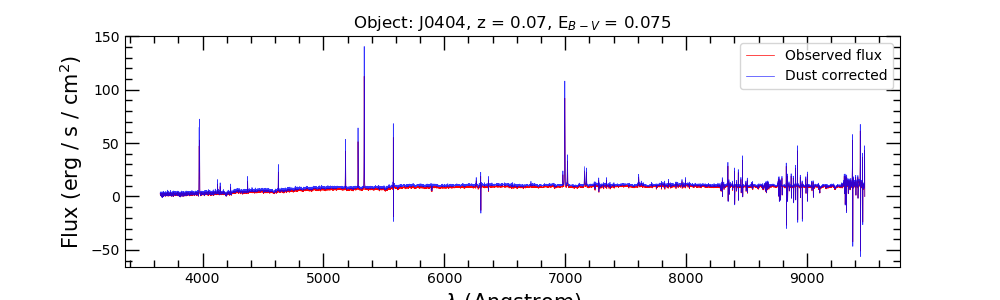

Saved figure at: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J0404/dcorr_J0404.pdf
Using uncorrected data


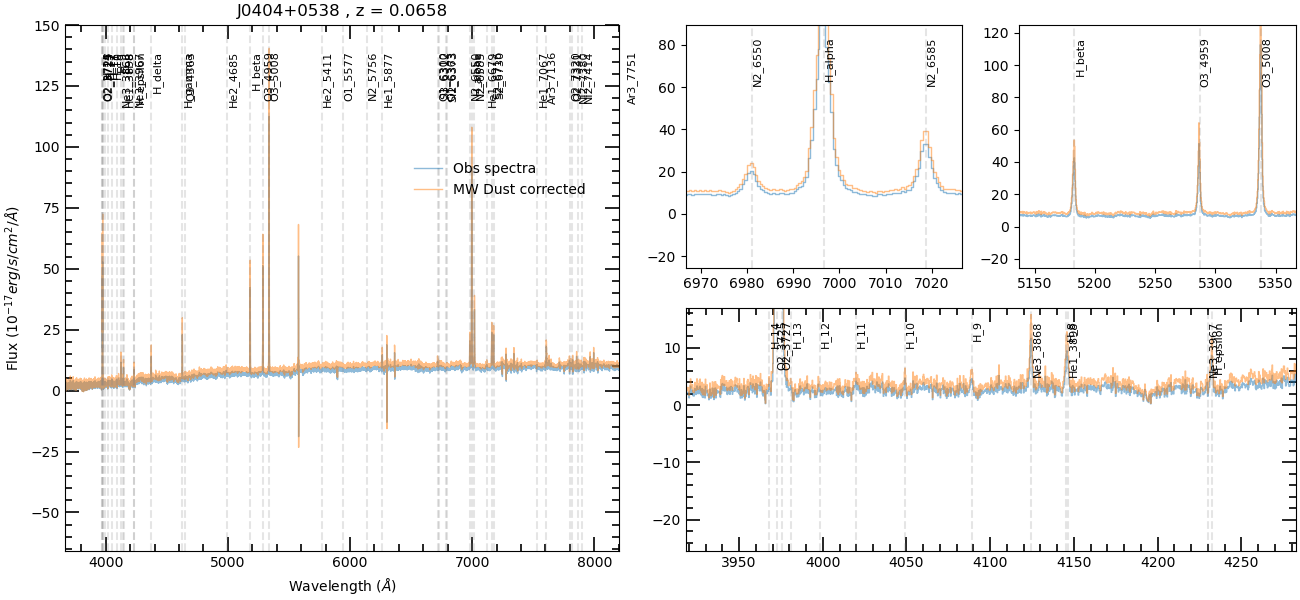

Saved MW dust corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/dust/J0404/dcorr_J0404.csv
Executed MW_dust_corr in 0.9632s


In [4]:
MW_DUST_CORR(J0404, plot=True)

Reading data for J0404
Using MW dust corrected data
Performing Balmer absorption correction for J0404


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:465: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


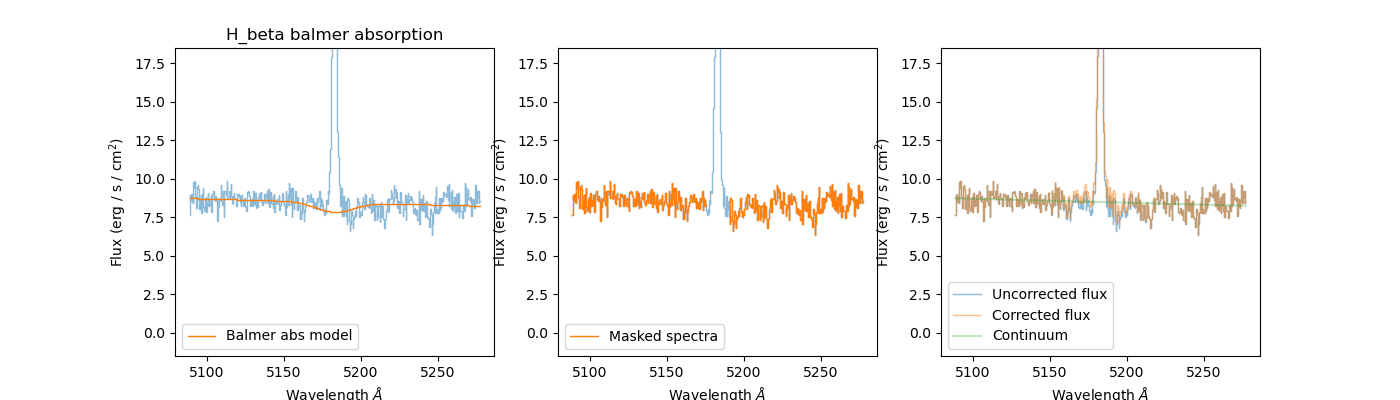

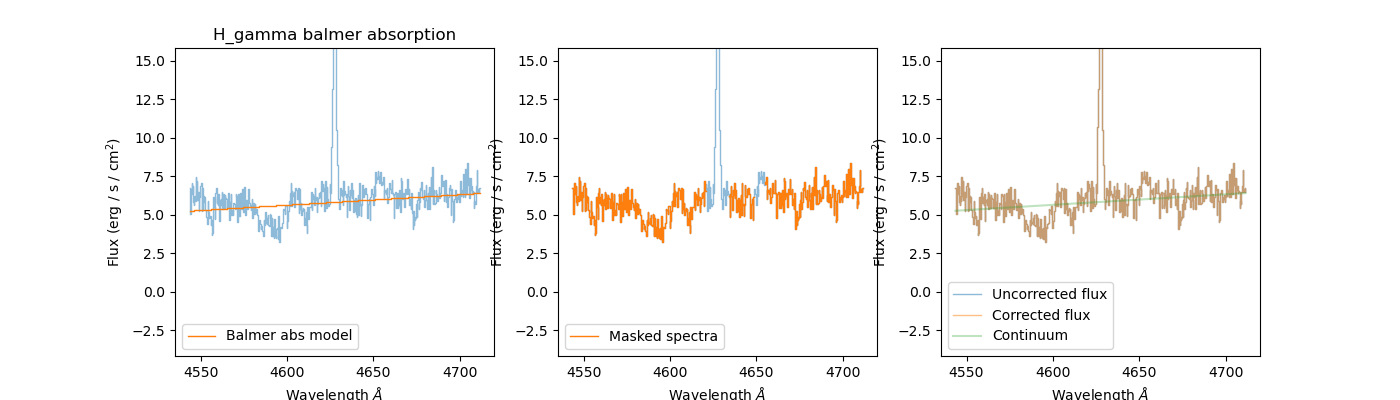

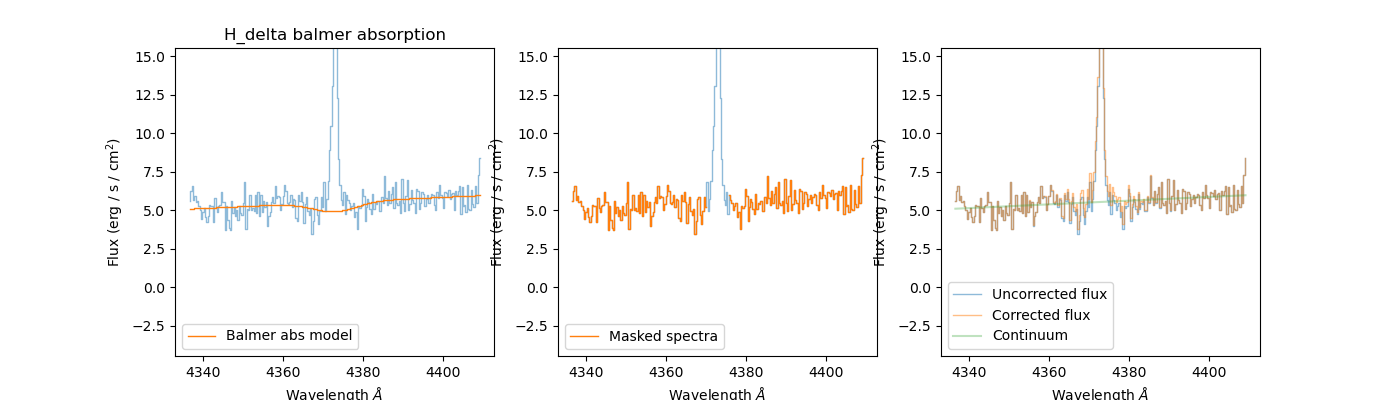

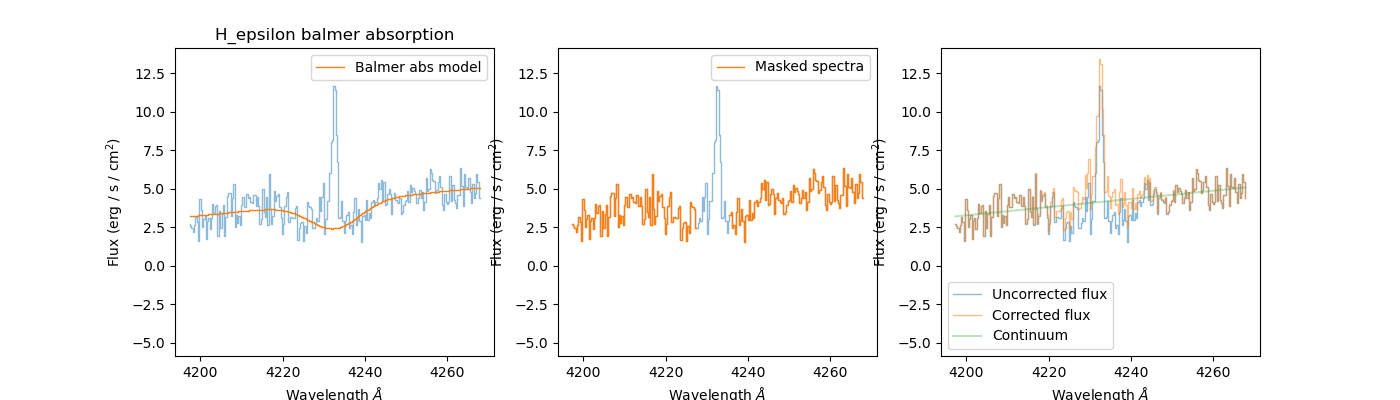

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:608: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, axs = plt.subplots(1, 3, figsize=(14, 4))


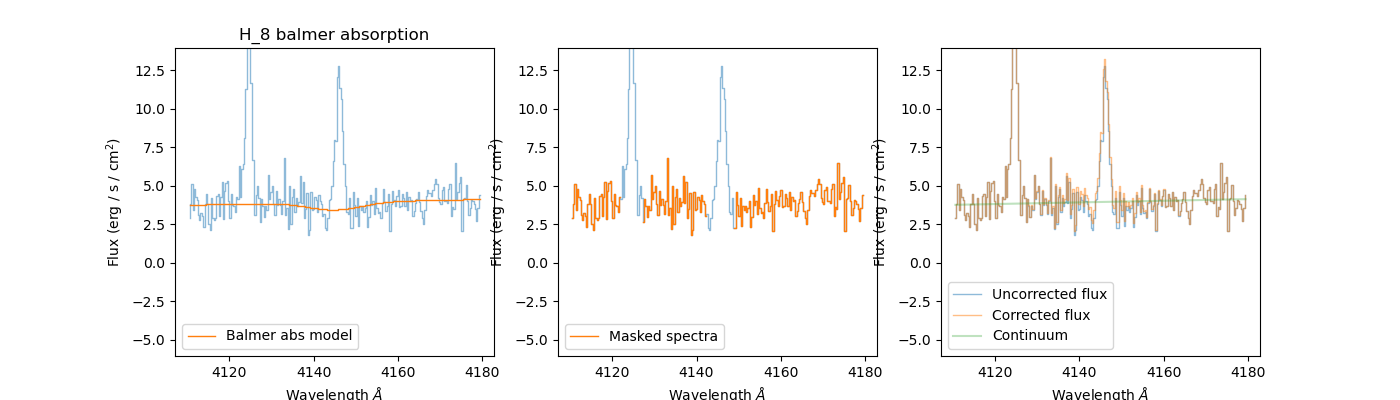

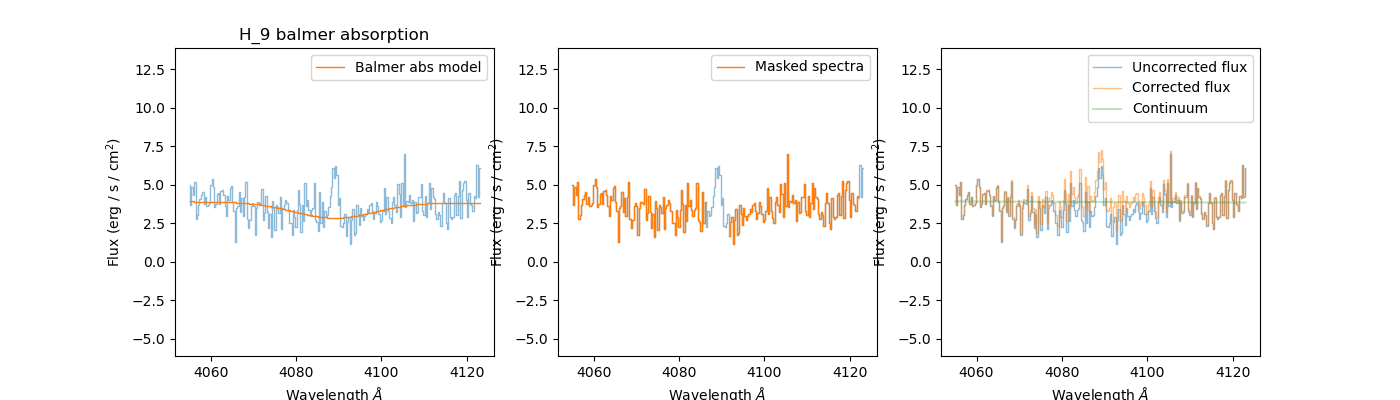

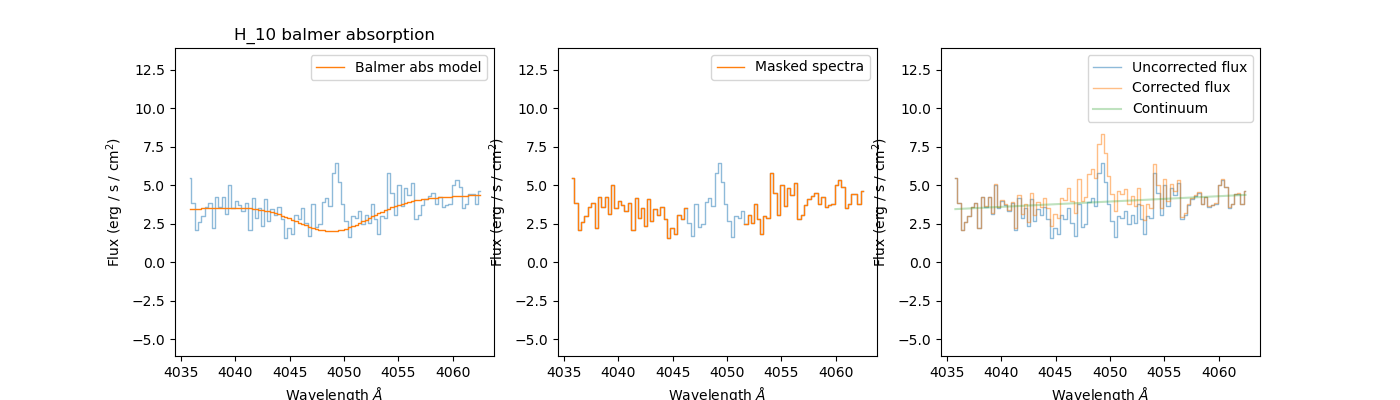

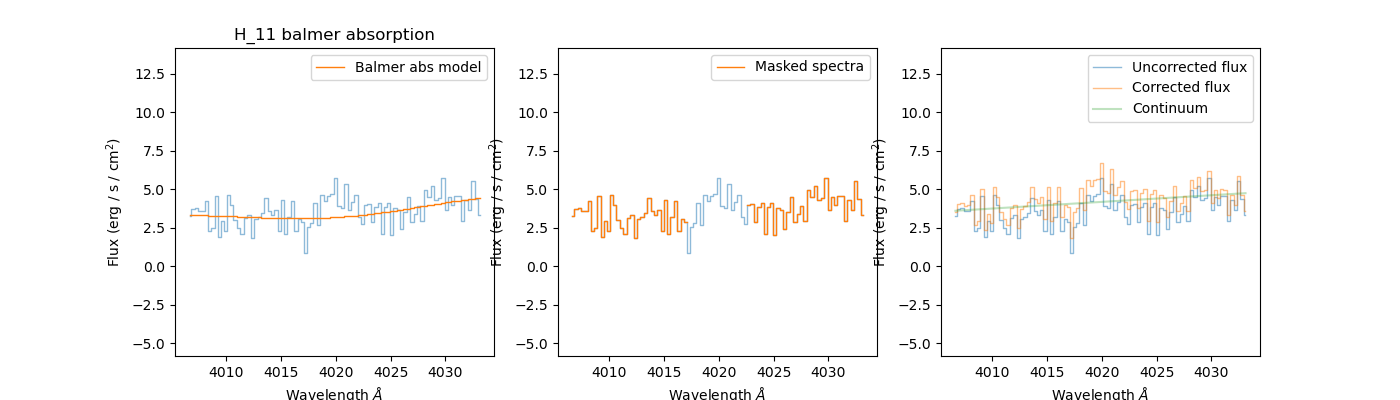

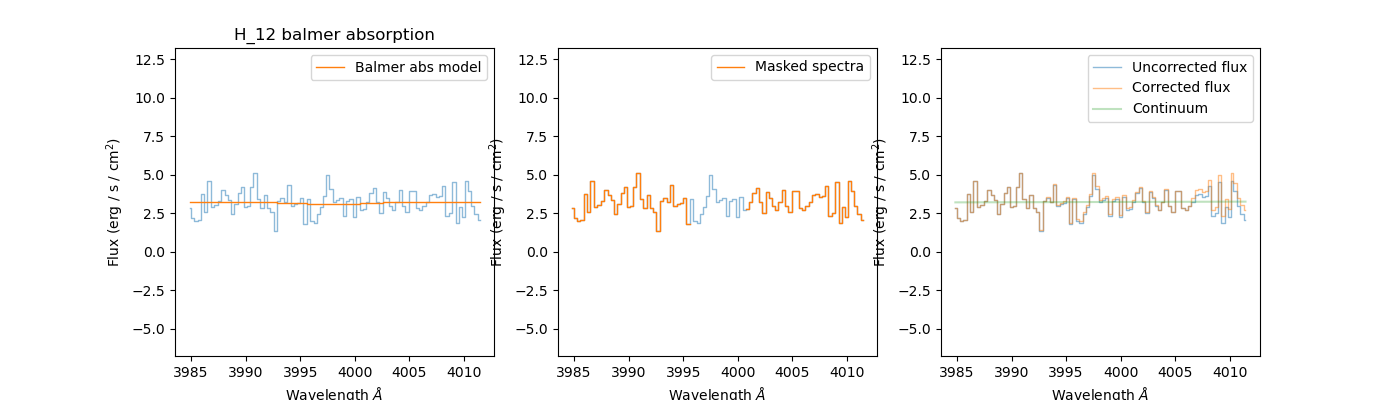

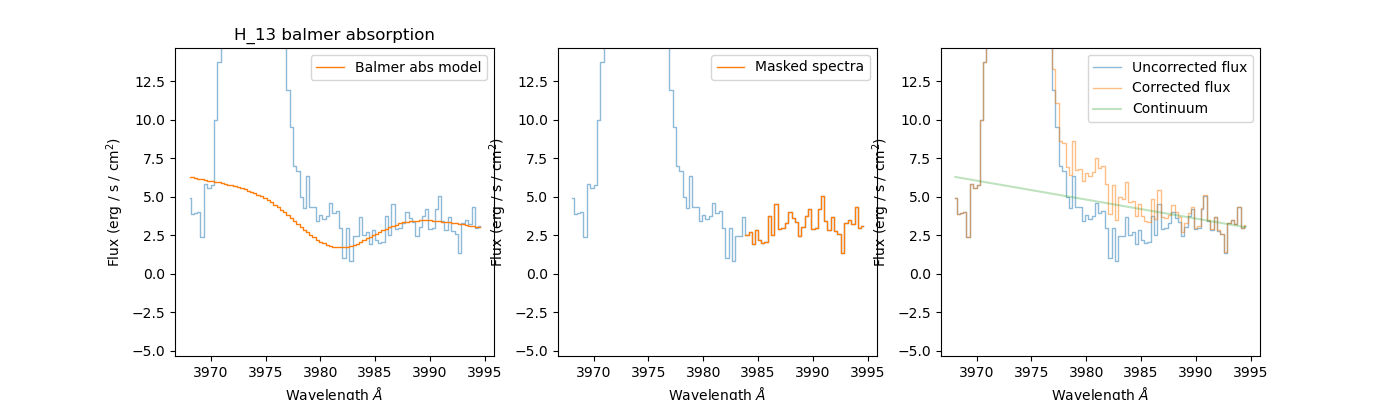

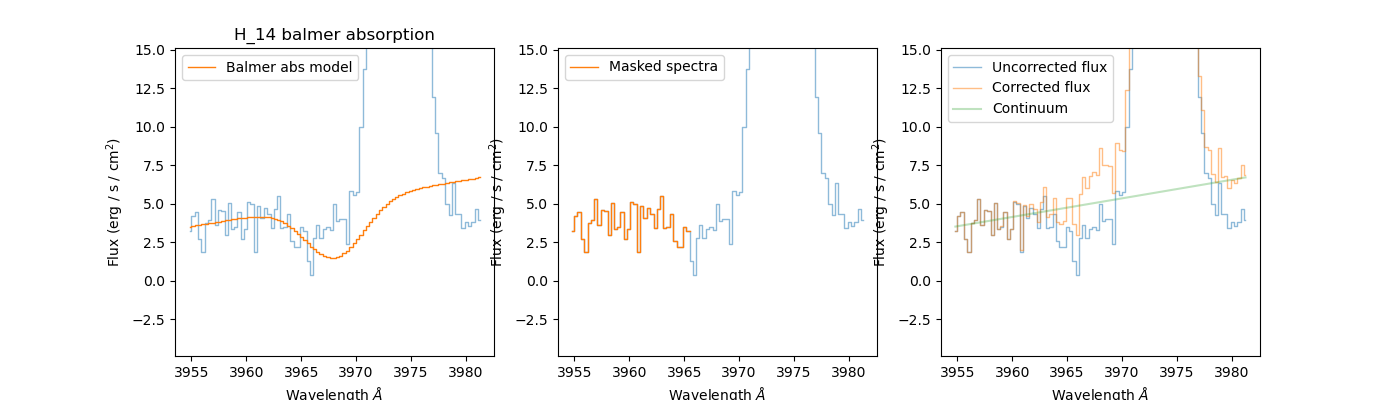

Using MW dust + Balmer abs corrected  data


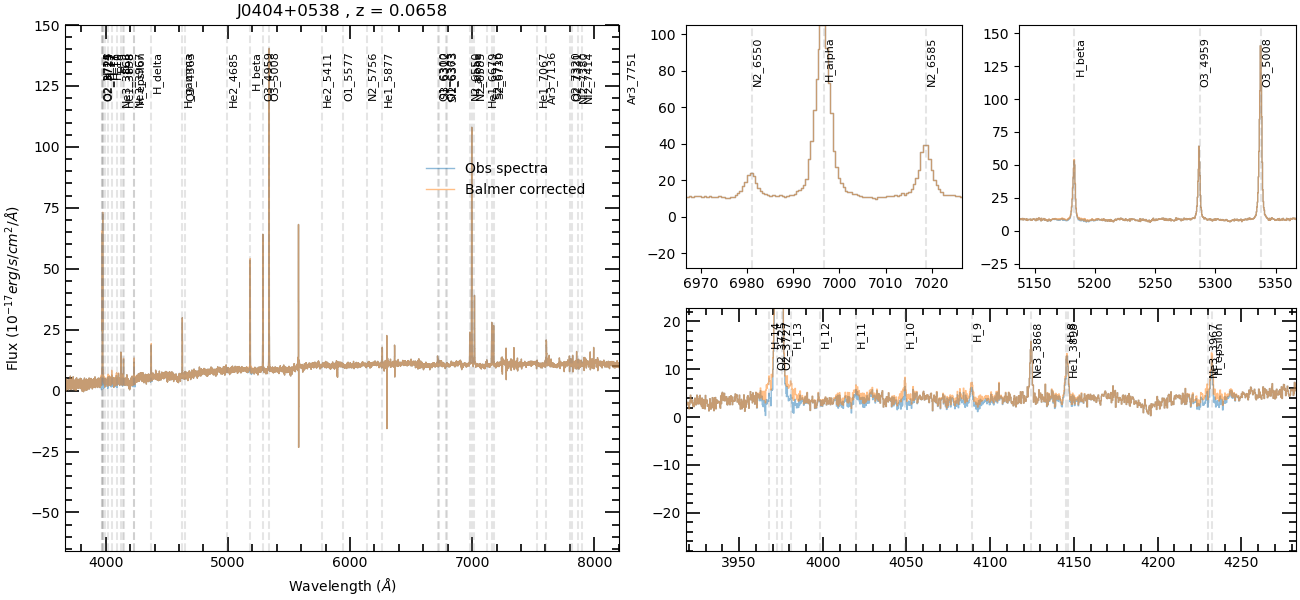

Saved Balmer Absorption corrected data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/bcorr_J0404.csv
Balmer absorption correction done!
Executed bal_abs_corr in 14.7548s


In [5]:
b = BALMER_ABS(J0404, showplot=True)

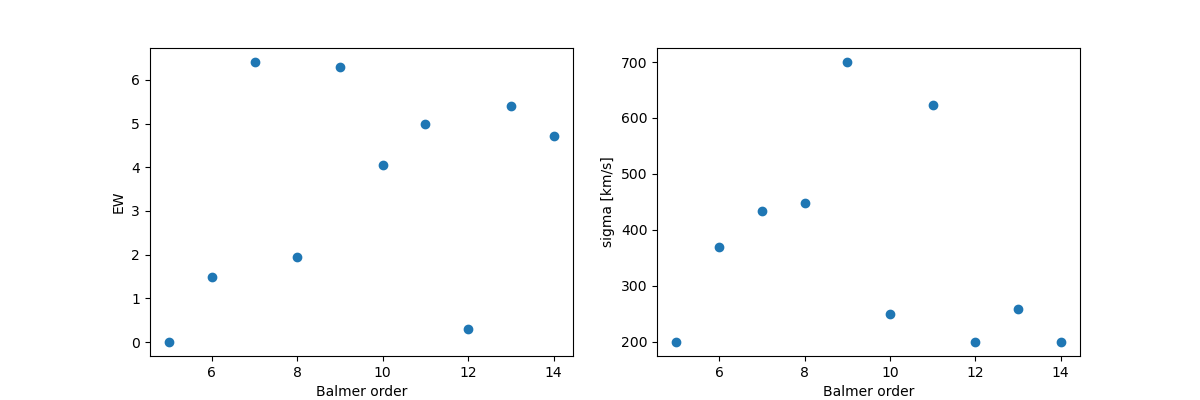

,ID,z,name,sigma,EW
0,J0404+0538,0.06582,H_beta,700.000000,-2.288472e+00
1,J0404+0538,0.06582,H_gamma,200.000000,-1.710349e-08
2,J0404+0538,0.06582,H_delta,369.127552,-1.492482e+00
3,J0404+0538,0.06582,H_epsilon,434.512479,-6.410256e+00
4,J0404+0538,0.06582,H_8,447.338943,-1.949555e+00
5,J0404+0538,0.06582,H_9,700.000000,-6.300353e+00
6,J0404+0538,0.06582,H_10,249.484428,-4.057271e+00
7,J0404+0538,0.06582,H_11,622.812108,-4.995405e+00
8,J0404+0538,0.06582,H_12,199.999776,-3.043116e-01
9,J0404+0538,0.06582,H_13,259.786882,-5.397349e+00


In [6]:
b.EW()

Reading data for J0404
Using MW dust + Balmer abs corrected  data
Calculating the first initial params


/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/corr.py:916: RuntimeWarning: divide by zero encountered in divide
  weights=1/self.sigma**2,


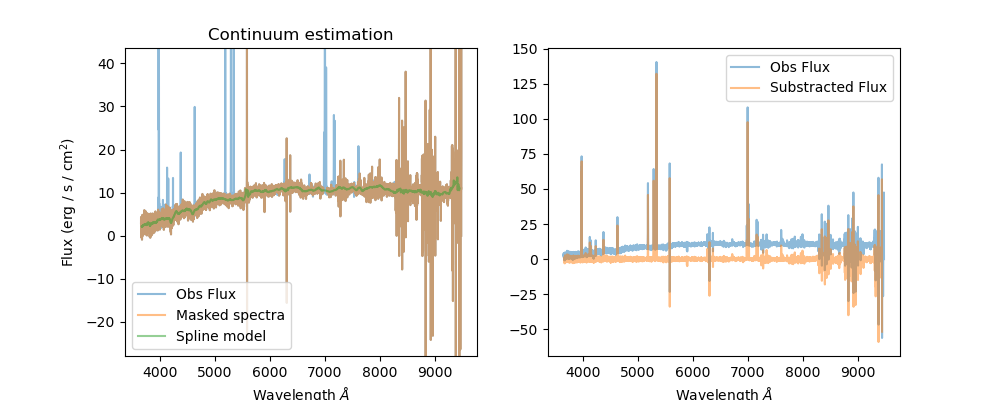

Executed cont_est in 12.1233s
Using MW dust + Balmer abs corrected and continuum substracted data


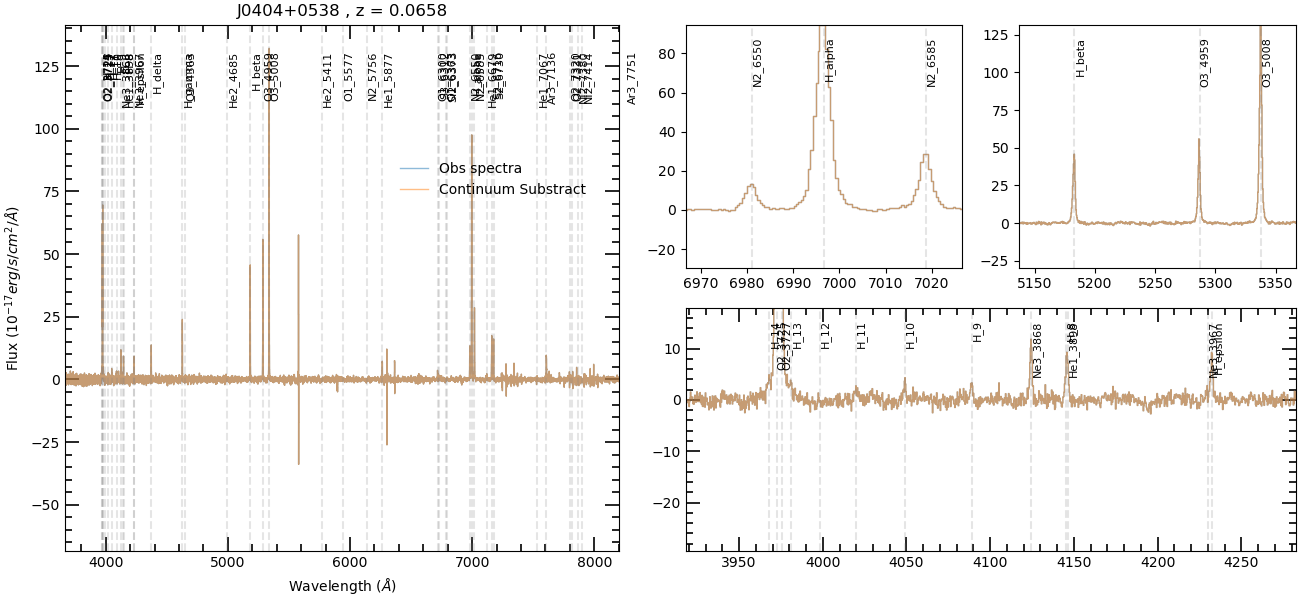

Saved continuum substracted data to: /Users/javieratoro/Desktop/thesis/proyecto 2024-2/cont_subs/J0404/cont_corr_J0404.csv


In [3]:
CONTINUUM_SUBSTRACT(J0404)

Reading data for J0404
Using MW dust + Balmer abs corrected and continuum substracted data


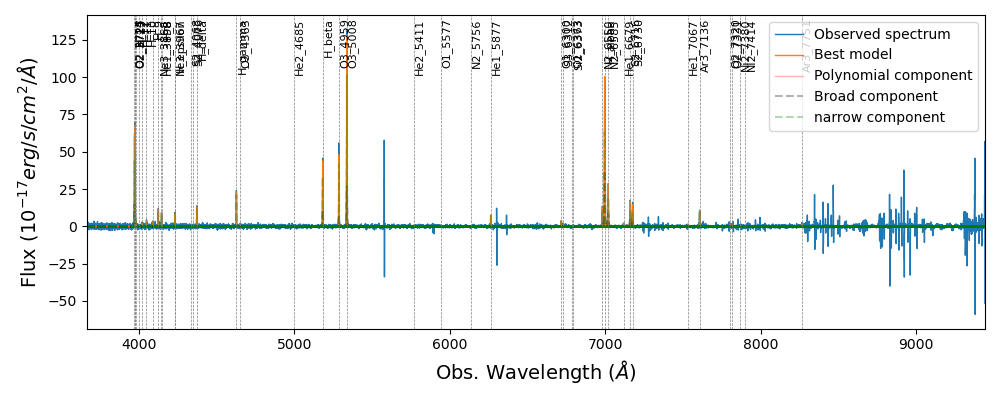

In [3]:
red = REDUC_LINES(J0404)
fit = red.fit_spectra(show_Plot=True)

In [5]:
print(2 * (z.z_chain.max() - z.z_chain.min()) * red.spectra.linelist_dict['H_alpha']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (z.z_chain.max() - z.z_chain.min()) * red.spectra.linelist_dict['H_beta']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (z.z_chain.max() - z.z_chain.min()) * red.spectra.linelist_dict['O3_5008']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (z.z_chain.max() - z.z_chain.min()) * red.spectra.linelist_dict['O3_4363']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (z.z_chain.max() - z.z_chain.min()) * red.spectra.linelist_dict['N2_6550']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))
print(2 * (z.z_chain.max() - z.z_chain.min()) * red.spectra.linelist_dict['N2_6585']*(1+red.spectra.redshift) / (red.wave[1]-red.wave[0]))

4.311013707571718
3.19336853929298
3.2889524220603565
2.8661636640690347
4.301346259269305
4.32459997981594


In [10]:
red.fit_MC(numMC=100)

Calculating the first initial params
Starting MC iteration
Executed fit_MC in 1164.3276s


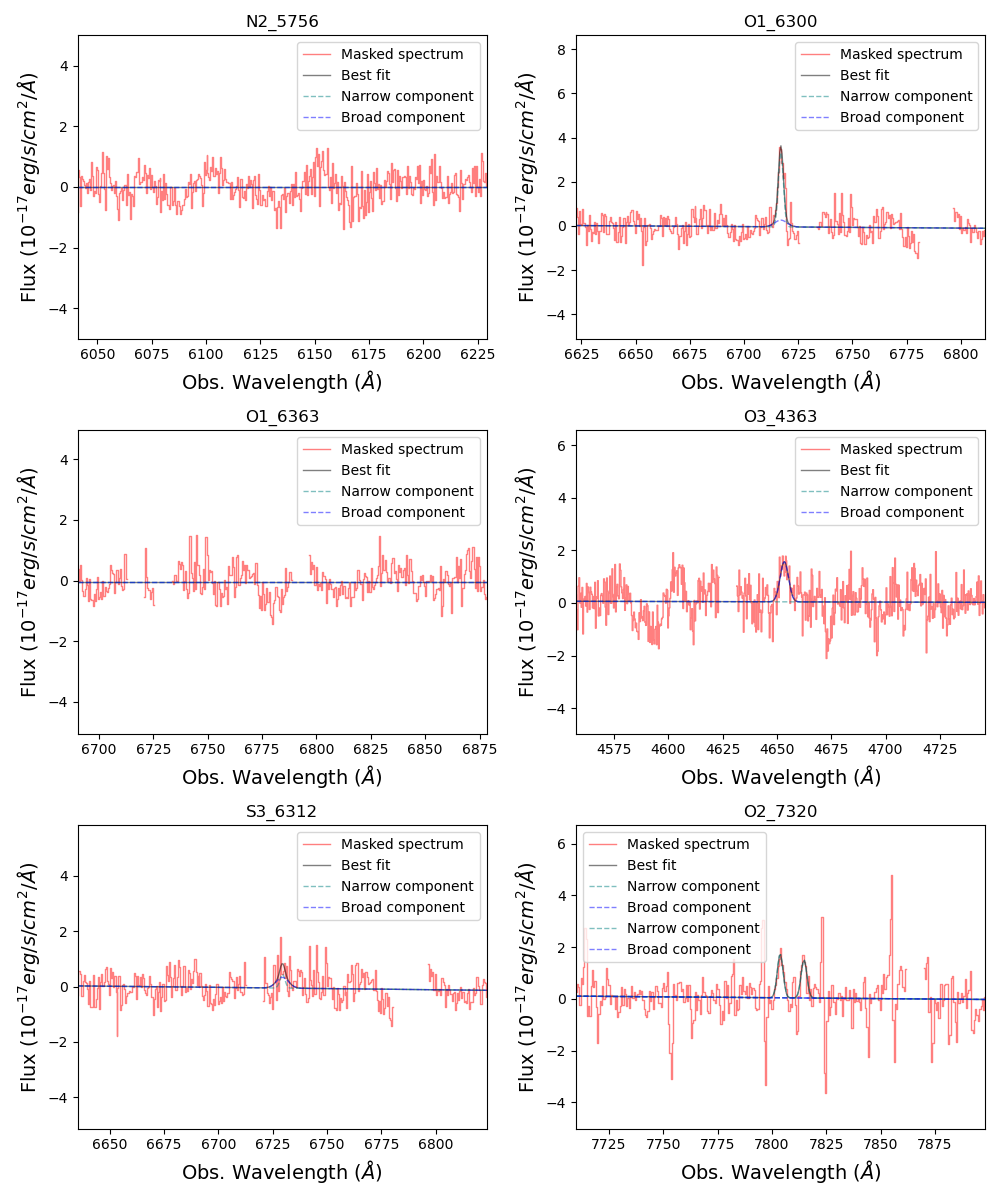

,sigma_v_narrow,sigma_v_broad,N2_5756_narrow_amplitude,N2_5756_broad_amplitude,O1_6300_narrow_amplitude,O1_6300_broad_amplitude,O1_6363_narrow_amplitude,O1_6363_broad_amplitude,O3_4363_narrow_amplitude,O3_4363_broad_amplitude,S3_6312_narrow_amplitude,S3_6312_broad_amplitude,O2_7320_narrow_amplitude,O2_7320_broad_amplitude,O2_7331_narrow_amplitude,O2_7331_broad_amplitude
0,51.439879,124.907213,4.032108e-12,5.354956e-07,9.714053,2.148012,8.799628e-13,0.000008,5.754924e-07,7.411587,1.453329,2.722624,5.673215,8.837014e-07,4.949046,7.270794e-07


In [4]:
red.fit_auroral(red.wave, red.flux, showplot=True)

In [5]:
red.fit_MC_auroral(numMC=100)

/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/lines.py:381: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  info = pd.concat([info, df], ignore_index=True)


Executed fit_MC_auroral in 34.0265s


,ID,mass,z,name,flux,fluxerr,narrow_flux,narrow_fluxerr,broad_flux,broad_fluxerr
0,J0404+0538,10.2,0.06582,N2_5756,2.133349e-07,0.000001,3.732681e-12,4.982935e-08,2.014085e-07,0.000001
1,J0404+0538,10.2,0.06582,O1_6363,1.294589e-05,36.864189,5.117906e-12,3.526076e+01,1.272817e-05,2.826455
2,J0404+0538,10.2,0.06582,O3_4363,7.384213e+00,0.642376,8.331855e-08,1.683181e-01,7.345923e+00,0.672088
3,J0404+0538,10.2,0.06582,S3_6312,4.281705e+00,0.764233,1.271728e+00,9.094999e-01,3.000078e+00,1.467615
4,J0404+0538,10.2,0.06582,O2_7320,5.608711e+00,0.414738,5.608670e+00,4.147429e-01,6.953093e-08,0.000025
5,J0404+0538,10.2,0.06582,O2_7331,5.009709e+00,0.500916,4.952143e+00,5.056754e-01,1.245637e-07,0.191685
6,J0404+0538,10.2,0.06582,O2_7320_7331,1.060524e+01,0.659612,1.056461e+01,6.813987e-01,8.088650e-06,0.191682
